# Машинное обучение, DS-поток
## Задание ML.14

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.


**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash;  120 баллов.







In [193]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(palette='Set2')

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm
import umap

In [ ]:
# Bot check

# HW_ID: ds_ml14
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

# Profile:

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована


---
### Задача 1
Скачайте <a href="https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis">данные</a> о клиентах некоторой торговой сети.

Цель задачи &mdash; кластеризовать клиентов с целью модификации продукта под разные типы пользовательских кластеров. Например, вместо того, чтобы тратиться на продвижение нового продукта каждому клиенту, можно продавать продукт только в том кластере, где клиенты с наибольшей вероятностью его купят.

In [84]:
data = pd.read_csv("./marketing_campaign.csv", sep="\t")
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [85]:
data.shape

(2240, 29)

In [86]:
data['Dt_Customer'].max()

'31-12-2013'

In [87]:
for column in data.columns:
    print(column)
    print(np.unique(data[column]))
    print()

ID
[    0     1     9 ... 11187 11188 11191]

Year_Birth
[1893 1899 1900 1940 1941 1943 1944 1945 1946 1947 1948 1949 1950 1951
 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963 1964 1965
 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977 1978 1979
 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993
 1994 1995 1996]

Education
['2n Cycle' 'Basic' 'Graduation' 'Master' 'PhD']

Marital_Status
['Absurd' 'Alone' 'Divorced' 'Married' 'Single' 'Together' 'Widow' 'YOLO']

Income
[  1730.   2447.   3502. ... 162397. 666666.     nan]

Kidhome
[0 1 2]

Teenhome
[0 1 2]

Dt_Customer
['01-01-2013' '01-01-2014' '01-02-2013' '01-02-2014' '01-03-2013'
 '01-03-2014' '01-04-2013' '01-04-2014' '01-05-2013' '01-05-2014'
 '01-06-2013' '01-07-2013' '01-08-2012' '01-08-2013' '01-09-2012'
 '01-09-2013' '01-10-2012' '01-10-2013' '01-11-2012' '01-11-2013'
 '01-12-2012' '01-12-2013' '02-01-2013' '02-01-2014' '02-02-2013'
 '02-02-2014' '02-03-2013' '02-03-2014' '02-04-2013

In [88]:
data.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Посмотрим на признаки. Прочитайте также информацию о признаках на странице данных.

In [89]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Посмотрим на диапазон дат регистрации

In [90]:
data["Dt_Customer"].min(), data["Dt_Customer"].max()

('01-01-2013', '31-12-2013')

Но это ведь максимальные и минимальные с точки зрения строк. Нужно сначала привести к формату даты

Кажется, данные выгружены в конце 2014 года, соответственно, определим дату анализа

In [91]:
end_date = pd.Timestamp('2015-01-01')

Посчитаем для каждого клиента количество дней с момента регистрации

In [92]:
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%d-%m-%Y', errors='raise')
data["Dt_Customer"].min(), data["Dt_Customer"].max()

(Timestamp('2012-07-30 00:00:00'), Timestamp('2014-06-29 00:00:00'))

In [95]:
data["usage_time"] = (end_date - data["Dt_Customer"]) / pd.Timedelta('1 day')
data["usage_time"]

0       849.0
1       299.0
2       498.0
3       325.0
4       347.0
        ...  
2235    567.0
2236    205.0
2237    341.0
2238    342.0
2239    808.0
Name: usage_time, Length: 2240, dtype: float64

Создайте следующие признаки:
* возраст клиента на основе даты рождения
* сумма покупок по всем категориям
* общее количество детей, сложив `Kidhome` и `Teenhome`
* на основе количества детей и семейного положения (`Marital_Status`) определите *предполагаемый* размер семьи
* средние траты клиента в день в период пользования сервисом, поделив суммарные траты на количество дней от даты регистрации (*см. примечание далее*)

In [96]:
data['Age'] = end_date.year - data['Year_Birth']

In [97]:
data['MntSpent'] = data['MntFishProducts'] + data['MntFruits'] + data['MntGoldProds'] +\
data['MntMeatProducts'] + data['MntSweetProducts'] + data['MntWines']

In [98]:
data['NumKids'] = data['Kidhome'] + data['Teenhome']

In [99]:
has_couple = ((data['Marital_Status'] == 'Married') + (data['Marital_Status'] == 'Together')).astype(int)
data['FamilySize'] = 1 + data['NumKids'] + has_couple

*Примечание.*

Клиент может перестать пользоваться сервисом спустя какое-то время, поэтому корректнее было бы делить на время пользования сервисом. В данных не сказано о том, в каких случаях клиента можно отнести в отток, а так же не указан принцип выгрузки данных (все клиенты или только активные), но имеется признак `Recency` &mdash; количество дней с момента последней покупки клиента.

Исследуйте этот признак и попробуйте понять, можно ли из данных сделать вывод о том, какие типы клиентов присутствуют в данных, каких клиентов можно отнести в отток. Если это сделать удалось, то при вычислении средних трат клиента в день делить нужно на количество дней использования сервиса в случае, если клиент попал в отток. Если клиент активен, то мы считаем, что он до сих пор пользуется сервисом, даже если последнюю покупку он совершал несколько дней назад.

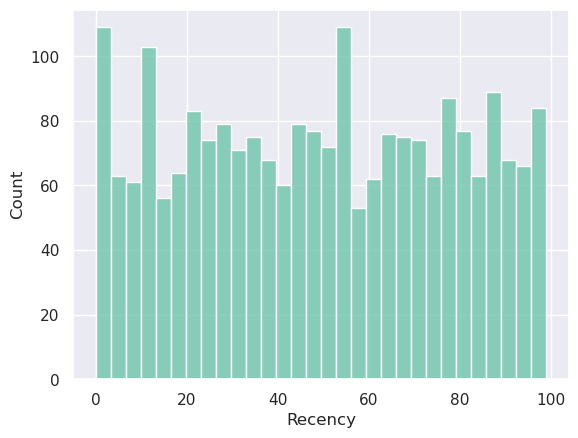

In [100]:
sns.histplot(data['Recency'], bins=30)
plt.show()

In [101]:
X = data[['Recency']]
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
data['Recency_cluster'] = kmeans.labels_

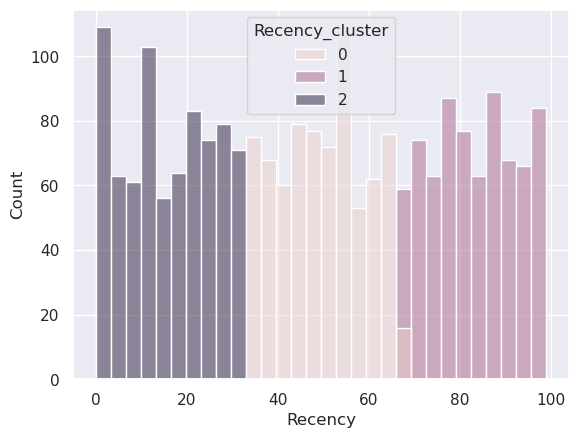

In [102]:
sns.histplot(
    data=data[['Recency', 'Recency_cluster']],
    x='Recency',
    bins=30,
    hue='Recency_cluster',
)
plt.show()

In [105]:
cond = data['Recency_cluster'] != 1

data['Spendings'] = np.where(
    cond,
    data['MntSpent'] / data['usage_time'],
    data['MntSpent'] / (data['usage_time'] - data['Recency'])
)

Далее будем работать с признаками:
* возраст клиента
* предполагаемый размер семьи
* средние траты клиента в день
* `Income` &mdash; годовой доход клиента

Проведите графическое исследование признаков. При необходимости выполните предобработку, обосновав ее необходимость.

In [106]:
columns = ['Age', 'FamilySize', 'Spendings', 'Income']

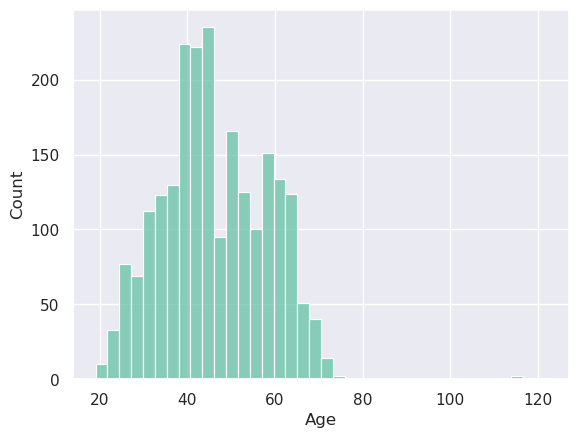

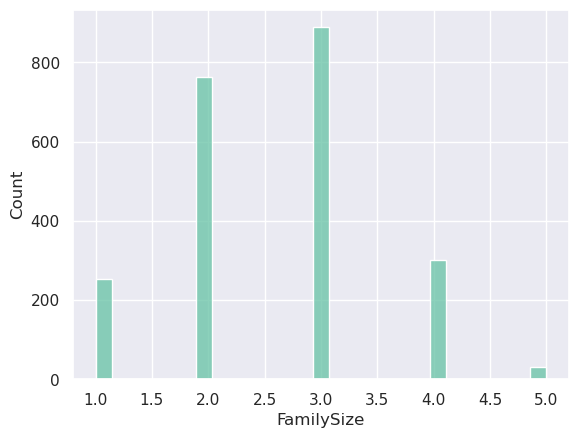

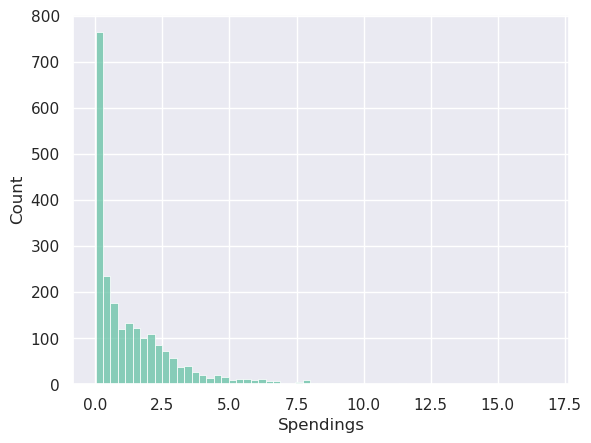

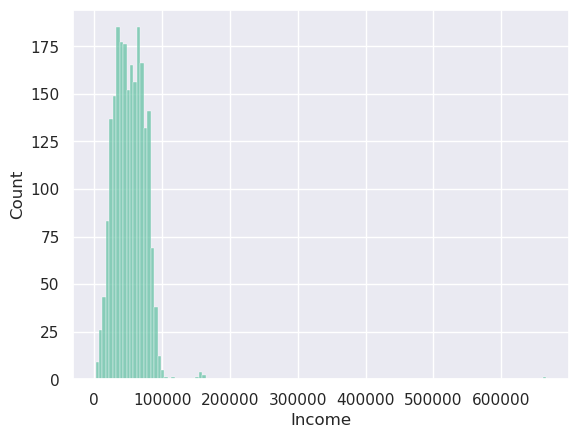

In [108]:
for column in columns:
    sns.histplot(data[column])
    plt.show()

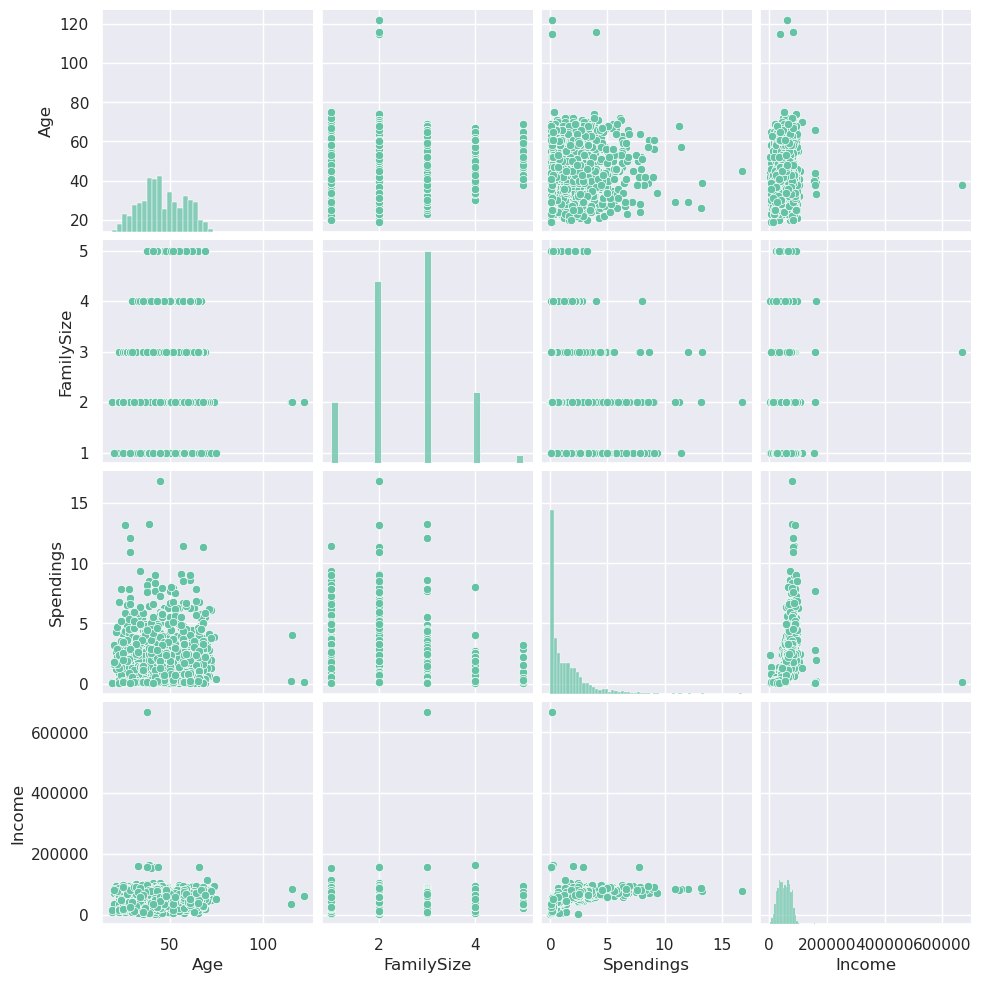

In [118]:
sns.pairplot(data[columns])
plt.show()

Очень странно, что есть множество стариков, которые зарабатывают больше среднестатестическиз людей, и между ними нет никакого перехода, вероятно выбросы

In [119]:
data = data[data['Age'] < 100]

Есть выбросы в зарплате

In [163]:
data = data[data['Income'] < 600000]

Есть ли в полученных данных пропуски? Если да, то насколько много, можно ли их удалить?

Да, пропуски есть, но их всего лишь 24. Можно удалить

In [164]:
data = data.dropna()

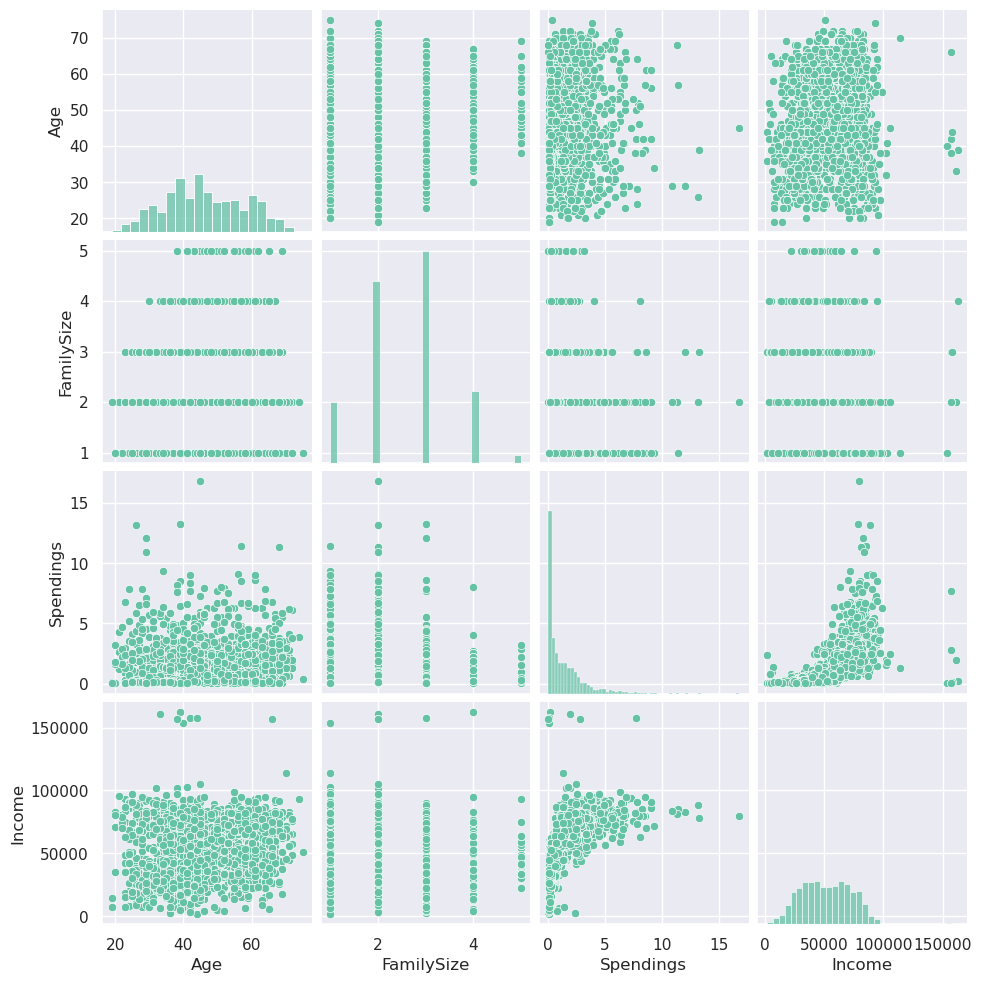

In [197]:
sns.pairplot(data[columns])
plt.show()

Перейдем к кластеризации клиентов. Какой метод кластеризации будете использовать и почему? Как определить оптимальное количество кластеров или, в зависимости от метода, других гиперпараметров?

In [201]:
X = data[columns]
X_scaled = StandardScaler().fit_transform(X)

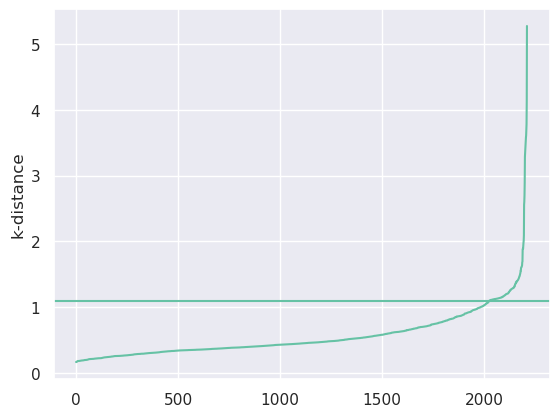

In [202]:
neighbors = NearestNeighbors(n_neighbors=20)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, -1])
plt.plot(distances)
plt.ylabel("k-distance")
plt.axhline(1.1)
plt.show()

Выполните кластеризацию этим методом и подберите оптимальное количество гиперпараметров.

In [203]:
db = DBSCAN(eps=1.1, min_samples=20).fit(X_scaled)
labels = db.labels_

In [204]:
silhouette_score(X_scaled, labels)

0.0984640704421352

In [205]:
data['dbscan_cluster'] = labels

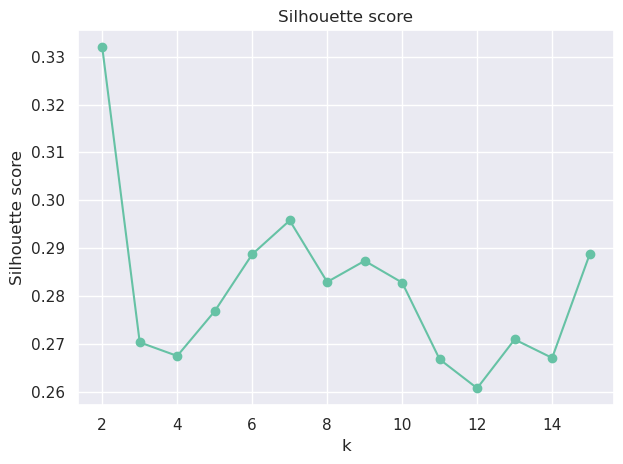

In [206]:
sil_scores = []
K = range(2, 16)   

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(K, sil_scores, '-o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette score')
plt.tight_layout()
plt.show()

For n_clusters = 2, average silhouette_score = 0.3321


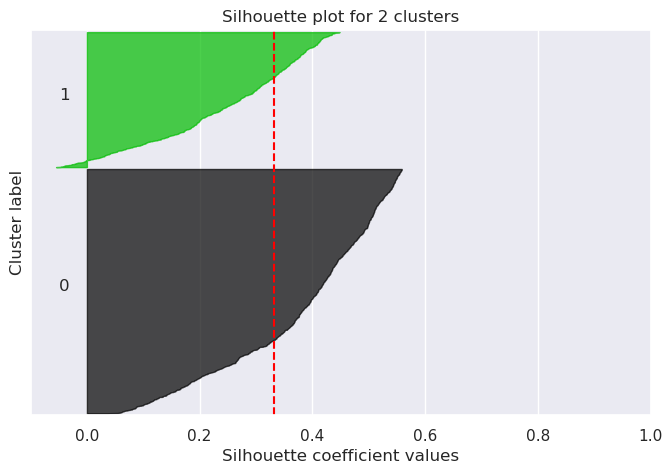

For n_clusters = 3, average silhouette_score = 0.2703


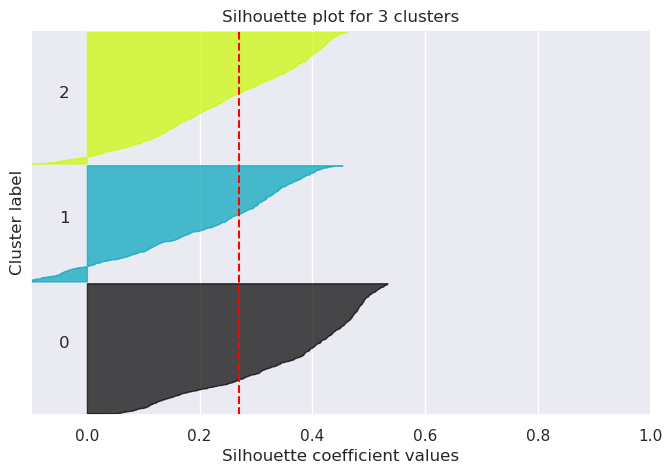

For n_clusters = 4, average silhouette_score = 0.2674


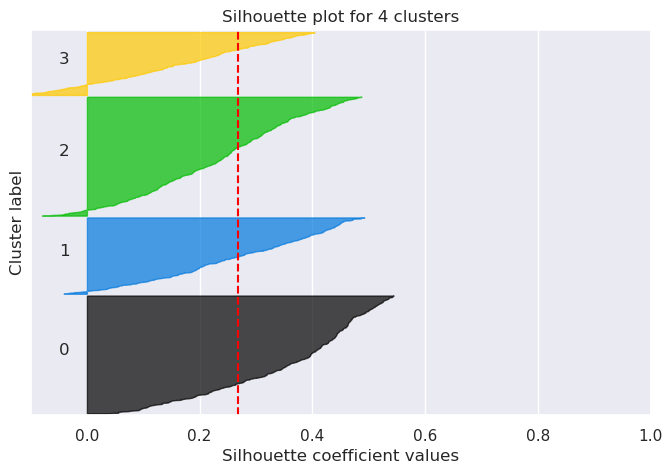

For n_clusters = 5, average silhouette_score = 0.2768


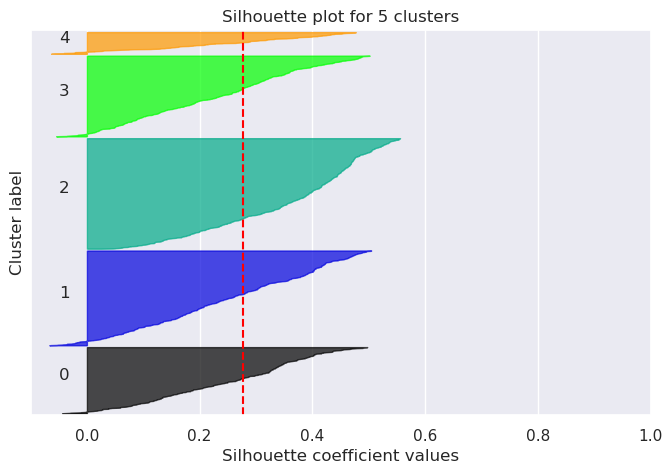

For n_clusters = 6, average silhouette_score = 0.2887


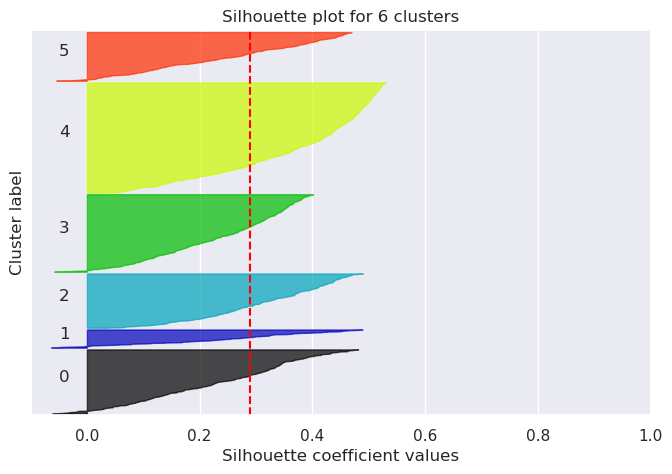

For n_clusters = 7, average silhouette_score = 0.2958


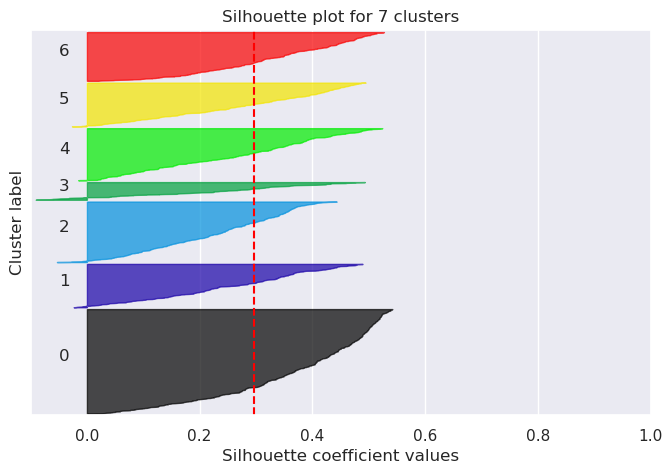

For n_clusters = 8, average silhouette_score = 0.2838


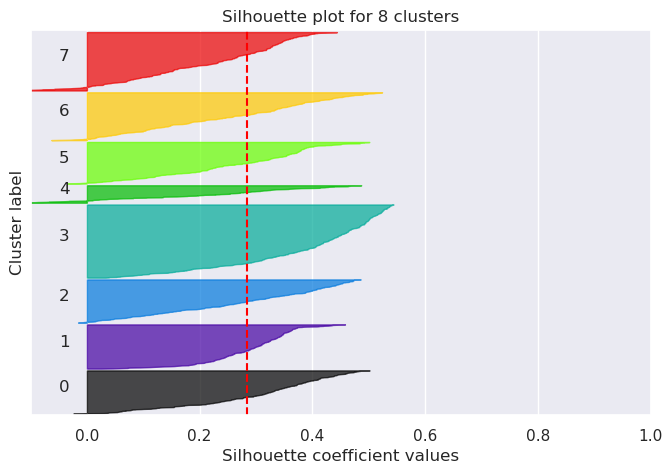

For n_clusters = 9, average silhouette_score = 0.2914


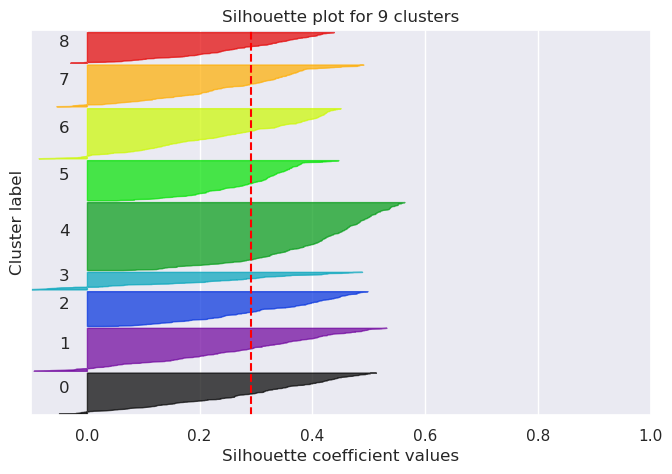

For n_clusters = 10, average silhouette_score = 0.2832


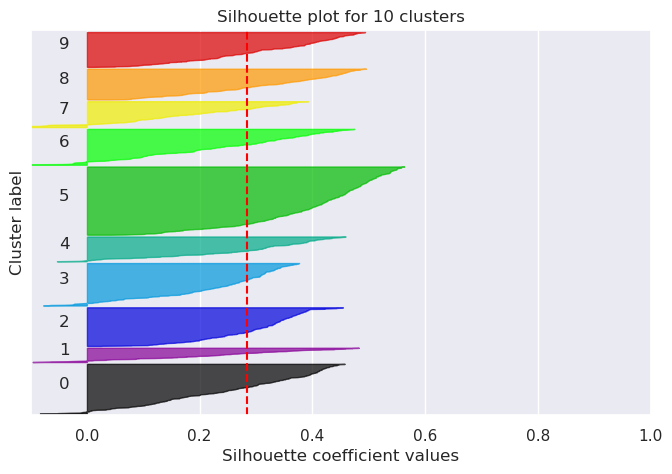

In [181]:
range_n_clusters = range(2, 11)

for n_clusters in range_n_clusters:
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])
    
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    cluster_labels = clusterer.fit_predict(X_scaled)

    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    print(f"For n_clusters = {n_clusters}, average silhouette_score = {silhouette_avg:.4f}")

    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)
    
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10  
    
    ax1.set_title(f"Silhouette plot for {n_clusters} clusters")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    plt.show()


In [207]:
k_final = 7
kmean = KMeans(n_clusters=k_final, random_state=42, n_init=20)
labels = kmean.fit_predict(X_scaled)         
data['kmeans_cluster'] = labels

Сколько элементов в каждом из полученных кластеров?

Проинтерпретируйте полученные кластеры с помощью визуального анализа. Используйте различные типы графиков (например, box plot), изученные ранее. Также проведите визуальный анализ используя UMAP. По каким признакам кластеры различаются, на сколько? Как можно описать клиентов каждого кластера?

Насколько кластеры соприкасаются друг с другом? Что можно сказать про клиентов на границе кластеров?

In [213]:
cluster_counts = data['dbscan_cluster'].value_counts().sort_index()
print("Количество элементов в каждом кластере:")
print(cluster_counts)

Количество элементов в каждом кластере:
dbscan_cluster
-1     54
 0    228
 1    872
 2    741
 3    293
 4     24
Name: count, dtype: int64


In [208]:
cluster_counts = data['kmeans_cluster'].value_counts().sort_index()
print("Количество элементов в каждом кластере:")
print(cluster_counts)

Количество элементов в каждом кластере:
kmeans_cluster
0    623
1    259
2    361
3    106
4    311
5    261
6    291
Name: count, dtype: int64


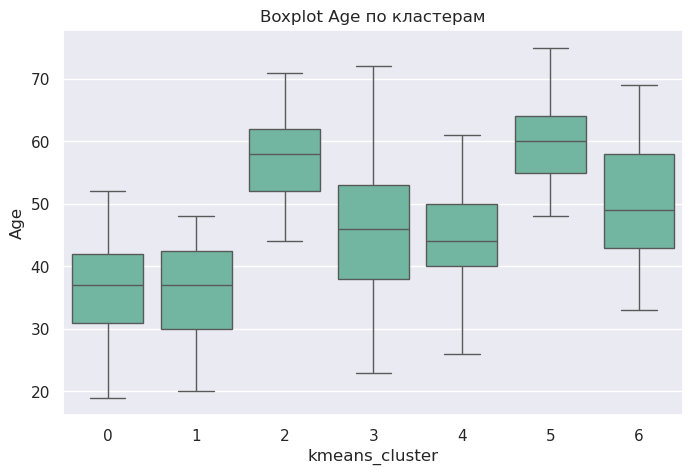

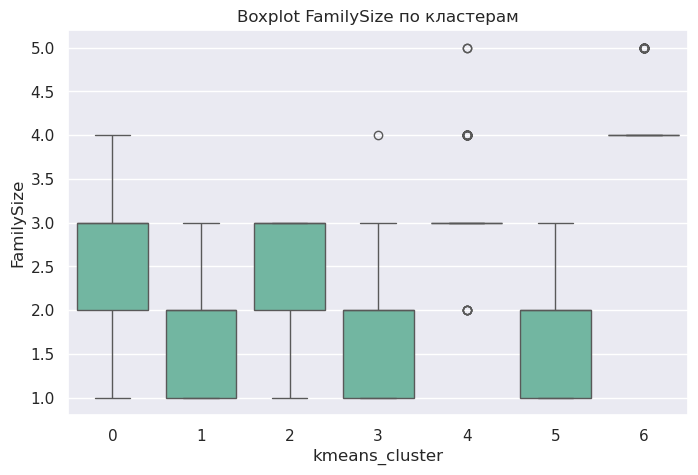

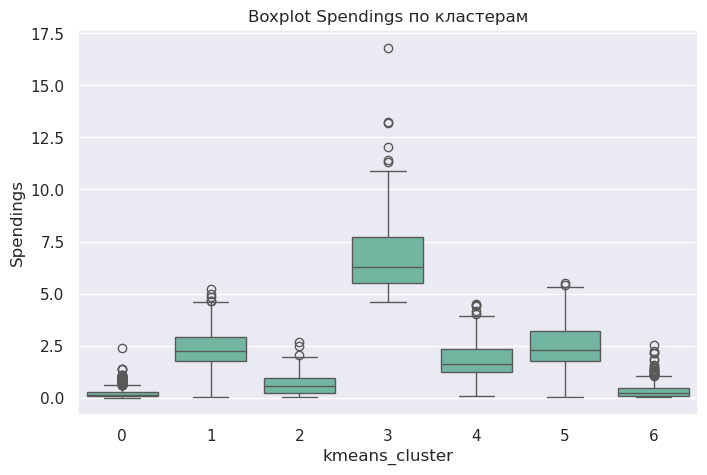

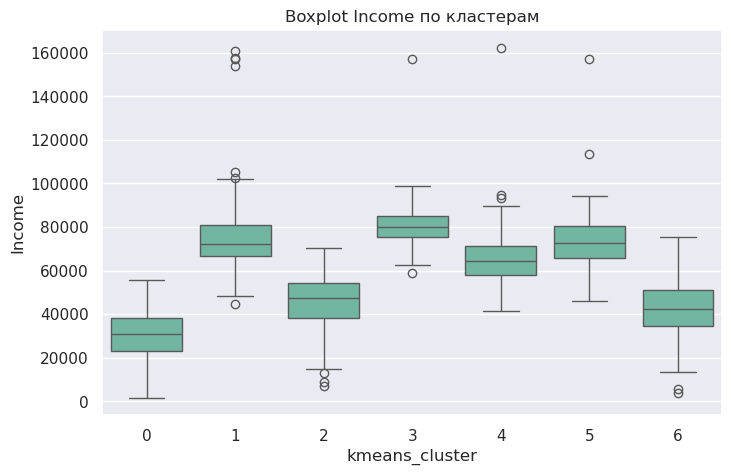

In [209]:
for feature in columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='kmeans_cluster', y=feature, data=data)
    plt.title(f'Boxplot {feature} по кластерам')
    plt.show()

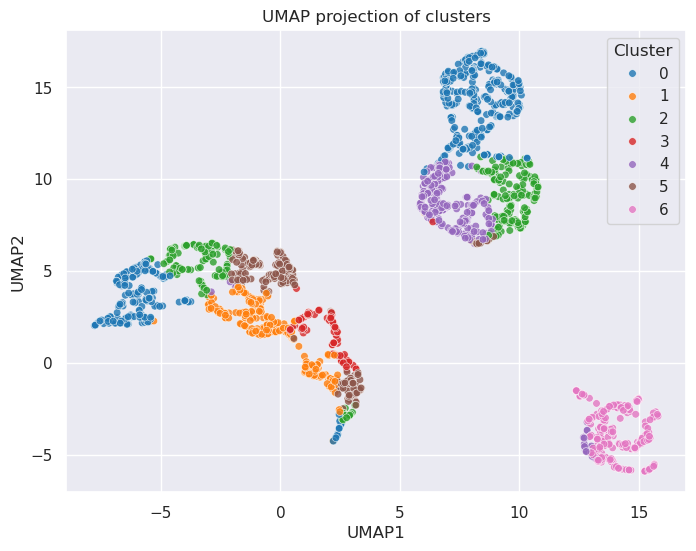

In [211]:
X = data[columns]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_jobs=-1)
embedding = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=embedding[:,0], y=embedding[:,1], hue=data['kmeans_cluster'], palette='tab10', s=30, alpha=0.8)
plt.title('UMAP projection of clusters')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(title='Cluster')
plt.show()

Попробуйте также применить другие изученные методы кластеризации. Насколько лучше или хуже получился результат?

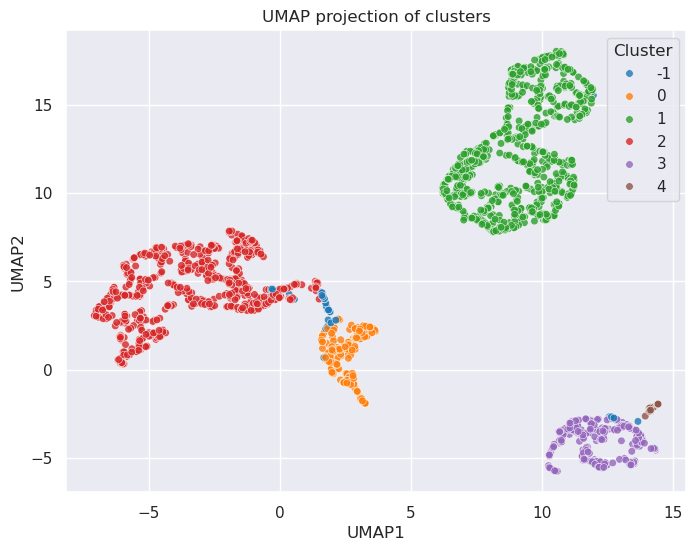

In [212]:
X = data[columns]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_jobs=-1)
embedding = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=embedding[:,0], y=embedding[:,1], hue=data['dbscan_cluster'], palette='tab10', s=30, alpha=0.8)
plt.title('UMAP projection of clusters')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(title='Cluster')
plt.show()

Не забывайте про выводы.

Kmeans возволяет получить более выоское качество по силуэту. Однако глядя на UMAP можно заметить, что DBSCAN позволяет получить визуально более осмысленный результат, хоть и с меньшим силуэтом. Также он помечает часть значений выбросами

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока